In [72]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

### **Read data from excel files**

In [73]:
df = pd.read_excel("data/dataset_adult.xlsx")

In [74]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [75]:
df.shape

(29904, 13)

In [76]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [77]:
df.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


### **Data Cleaning & Exploratory Data Analysis**

#### **Handling Missing Values**

In [78]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [79]:
df.dropna(inplace=True)

In [80]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

#### **Handling Duplicates**

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.drop_duplicates(inplace=True)

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.379910,23.364184,20892.303821
std,13.412657,1.431201,24.740339,6936.813440
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


#### **Data Cleaning: number_of_dependants**

In [85]:
df[df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-1, -3])

Negative values are present in `number_of_dependants`. Since the number of dependants cannot be negative, these values will be converted to their corresponding positive values.

In [86]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

In [87]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.385933,23.364184,20892.303821
std,13.412657,1.421137,24.740339,6936.813440
min,26.000000,0.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


### **1. Numeric Columns**

**Box plots for numeric columns**

In [88]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

In [89]:
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

#### **Outlier Treatment: Age Column**

In [90]:
df[df['age']>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [91]:
df1 = df[df.age<=100]

In [92]:
df1.age.describe()

count    29828.000000
mean        43.095380
std         11.041991
min         26.000000
25%         34.000000
50%         42.000000
75%         52.000000
max         72.000000
Name: age, dtype: float64

#### **Outlier Treatment: Income Column**

In [93]:
quantile_thresold = df1.income_lakhs.quantile(0.999)

In [94]:
quantile_thresold

np.float64(100.0)

In [95]:
df1[df1.income_lakhs>quantile_thresold].shape

(6, 13)

In [96]:
df2 = df1[df1.income_lakhs<=quantile_thresold].copy()

In [97]:
df2.shape

(29822, 13)

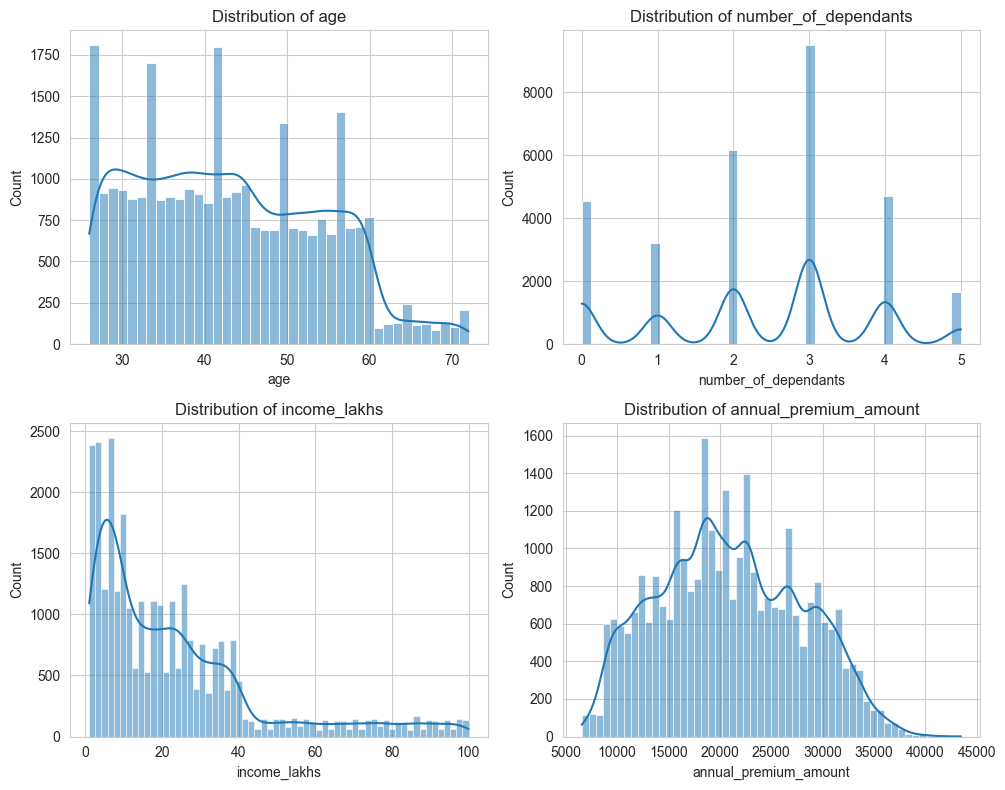

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=df2,x=column,kde=True,ax=ax)

    ax.set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

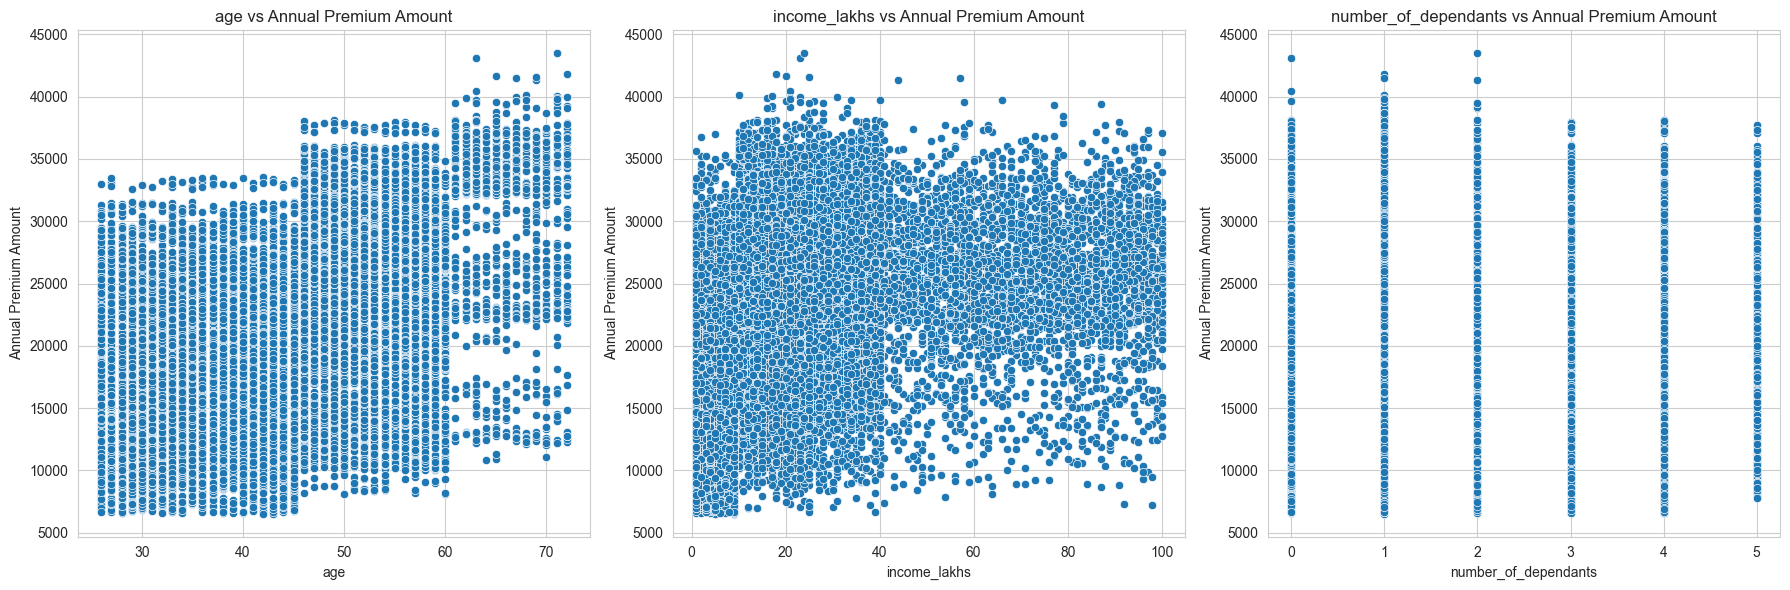

In [99]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1,len(numeric_features),figsize=(18, 6))

for ax, column in zip(axes, numeric_features):

    sns.scatterplot(data=df2,x=column,y='annual_premium_amount',ax=ax)

    ax.set_title(f'{column} vs Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()
plt.show()

### **2. Categorical Columns**

In [100]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [101]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})
df2['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

### **Feature Engineering**

In [102]:
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


#### **Calculate Risk Score**

In [103]:
# Define risk scores for each medical condition
risk_scores = {'diabetes': 6,'heart disease': 8,'high blood pressure': 6,'thyroid': 5,'no disease': 0,'none': 0}

# Split medical history into separate conditions
df2[['disease1', 'disease2']] = (df2['medical_history'].str.lower().str.split(' & ', expand=True))

# Handle missing values
df2[['disease1', 'disease2']] = (df2[['disease1', 'disease2']].fillna('none'))

# Calculate total risk score
diseases = ['disease1', 'disease2']

df2['total_risk_score'] = sum(df2[disease].map(risk_scores)for disease in diseases)

# Normalize risk score to a range of 0–1
df2['normalized_risk_score'] = (
    (df2['total_risk_score'] - df2['total_risk_score'].min()) / (df2['total_risk_score'].max() - df2['total_risk_score'].min()))

df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,diabetes,none,6,0.428571


#### **Encode Text Columns**

In [104]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Gold': 3,'Silver': 2,'Bronze': 1})

In [105]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [106]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [107]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

In [108]:
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [109]:
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,diabetes,none,6,...,0,0,0,1,0,0,1,0,0,1


In [110]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29822 entries, 0 to 29903
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              29822 non-null  int64  
 1   number_of_dependants             29822 non-null  int64  
 2   income_level                     29822 non-null  int64  
 3   income_lakhs                     29822 non-null  int64  
 4   medical_history                  29822 non-null  object 
 5   insurance_plan                   29822 non-null  int64  
 6   annual_premium_amount            29822 non-null  int64  
 7   disease1                         29822 non-null  object 
 8   disease2                         29822 non-null  object 
 9   total_risk_score                 29822 non-null  int64  
 10  normalized_risk_score            29822 non-null  float64
 11  gender_Male                      29822 non-null  int64  
 12  region_Northwest       

#### **Feature Selection**

In [111]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)

In [112]:
df4.head(5)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


#### **Calculate VIF for Multicolinearity**

In [113]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

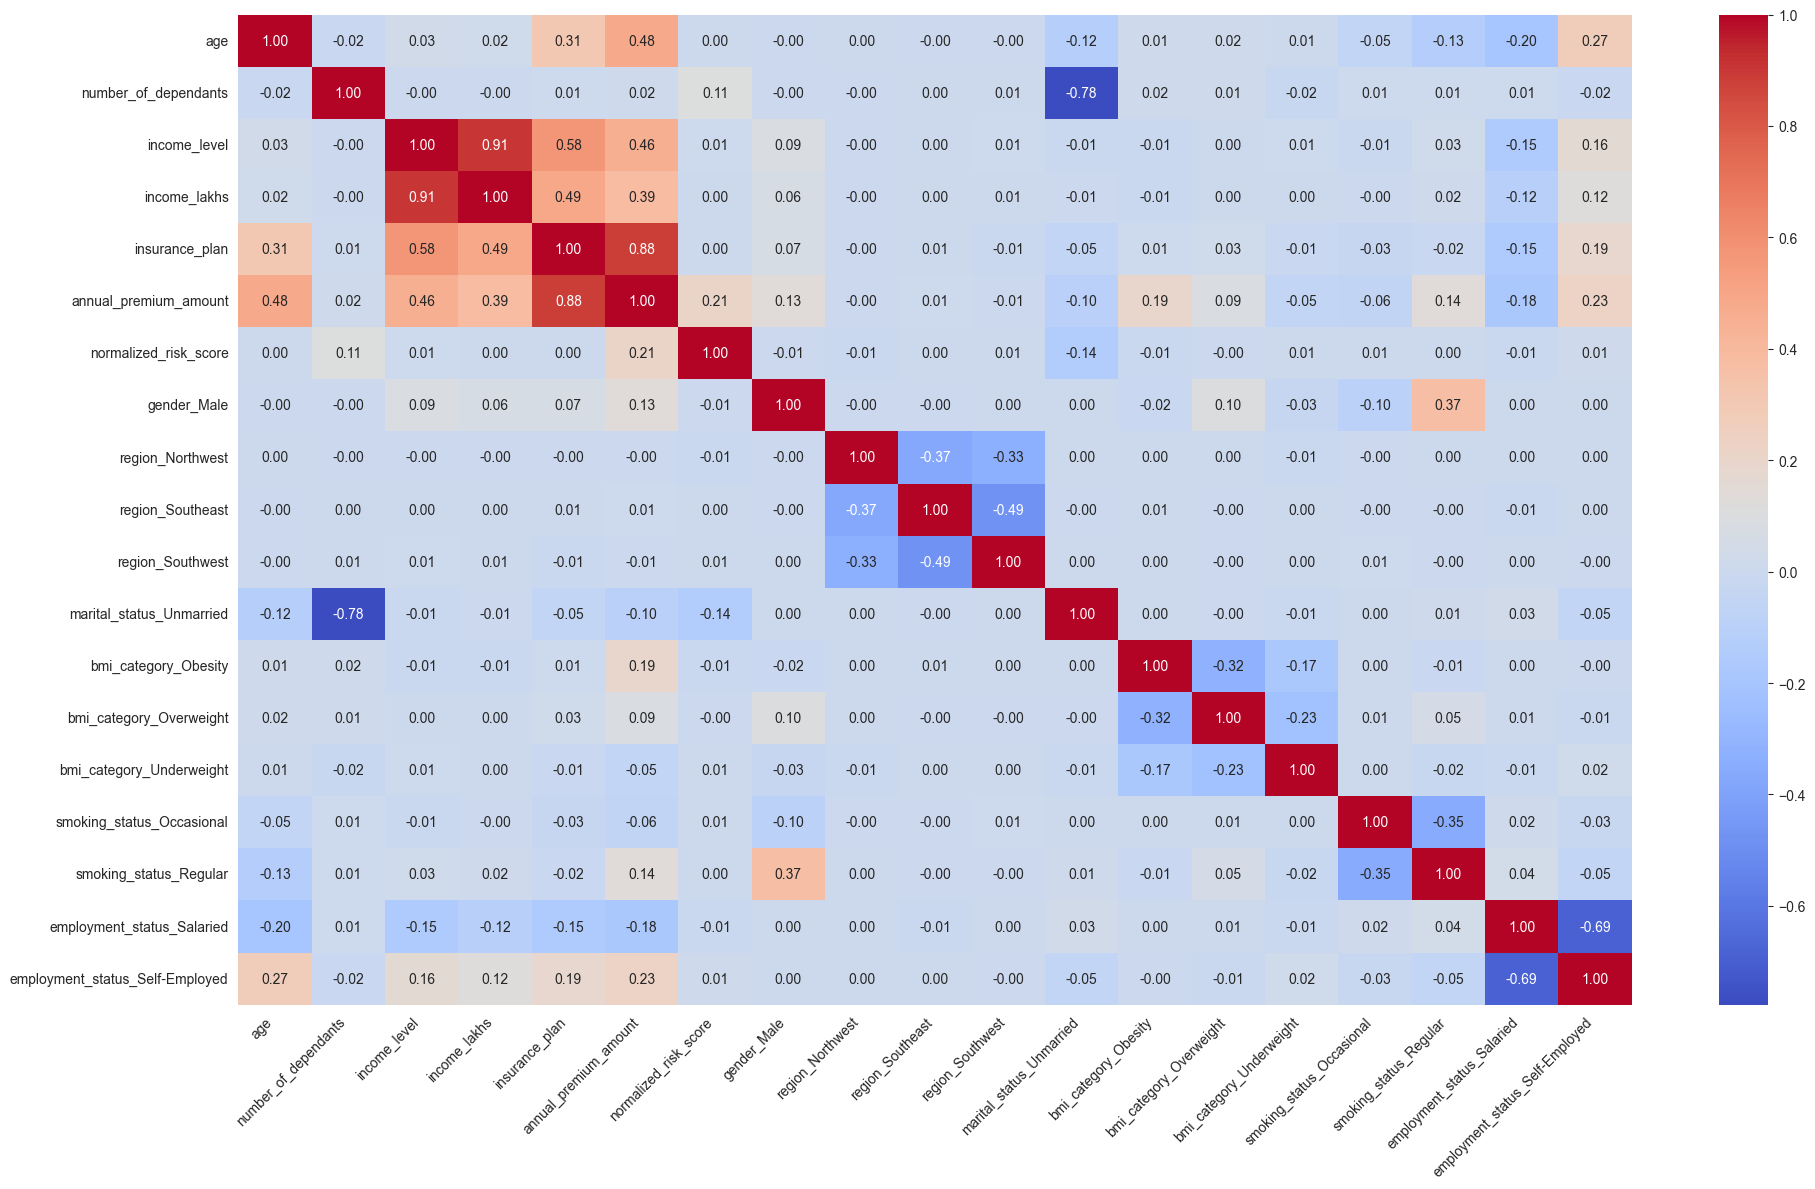

In [114]:
correlation_matrix = df4.corr()

plt.figure(figsize=(20, 12))

sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [115]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):

    vif_df = pd.DataFrame({
        'Column': data.columns,
        'VIF': [
            variance_inflation_factor(data.values, i)
            for i in range(data.shape[1])
        ]
    })

    return vif_df.sort_values(
        by='VIF',
        ascending=False
    ).reset_index(drop=True)

In [116]:
from sklearn.preprocessing import MinMaxScaler

X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

cols_to_scale = ['age','number_of_dependants','income_level','income_lakhs','insurance_plan']

scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(
    X[cols_to_scale]
)

X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [117]:
calculate_vif(X)

,Column,VIF
0,income_level,13.890522
1,income_lakhs,11.185596
2,number_of_dependants,6.278938
3,insurance_plan,5.271297
4,age,3.921783
5,normalized_risk_score,3.810619
6,employment_status_Salaried,3.177473
7,region_Southeast,2.980842
8,employment_status_Self-Employed,2.871687
9,region_Southwest,2.710097


In [118]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,number_of_dependants,6.278147
1,insurance_plan,4.574625
2,age,3.863055
3,normalized_risk_score,3.808345
4,employment_status_Salaried,3.169218
5,region_Southeast,2.979899
6,employment_status_Self-Employed,2.866611
7,region_Southwest,2.708641
8,income_lakhs,2.678102
9,gender_Male,2.591439


In [119]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop('income_level', axis="columns")

### **Model Training**

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (20875, 17)
x test:  (8947, 17)
y train:  (20875,)
y test:  (8947,)


#### **Linear Regression Model**

In [121]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9534163989489616, 0.9538448451629948)

In [122]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  2183844.360312456 RMSE:  1477.7835972538253


In [123]:
X_test.shape

(8947, 17)

In [124]:
np.set_printoptions(suppress=True, precision=6)

In [125]:
model_lr.coef_

array([ 7016.239328, -1311.764702,  -708.193369, 14835.988208,
        6053.624123,    37.558269,   -55.250872,   -19.622543,
         -22.289676,  -700.3202  ,  3926.812706,  1979.456047,
         612.866236,   837.395101,  2800.661843,   -45.491367,
         243.078421])

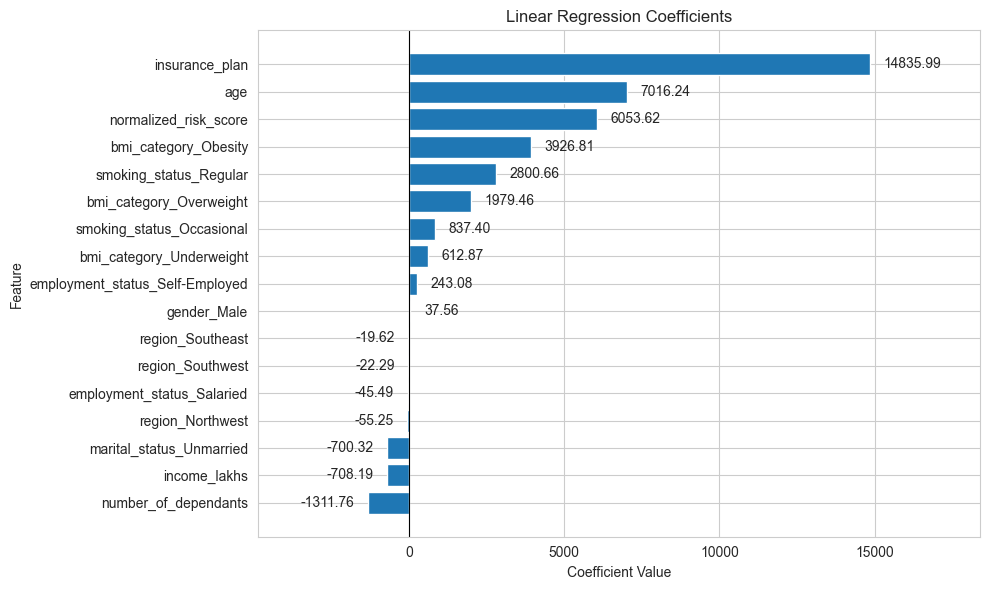

In [126]:
# Create a DataFrame of feature coefficients
coef_df = pd.DataFrame({'Feature': X_train.columns,'Coefficient': model_lr.coef_}).sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))

bars = plt.barh(coef_df['Feature'],coef_df['Coefficient'])

# Add coefficient labels
offset = coef_df['Coefficient'].abs().max() * 0.03

for bar in bars:
    width = bar.get_width()

    plt.text(width + offset if width > 0 else width - offset,bar.get_y() + bar.get_height() / 2,f'{width:.2f}',va='center',
        ha='left' if width > 0 else 'right')

# Add padding on both sides
xmin = coef_df['Coefficient'].min() - offset * 8
xmax = coef_df['Coefficient'].max() + offset * 8
plt.xlim(xmin, xmax)

plt.axvline(x=0, color='black', linewidth=0.8)

plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients')

plt.tight_layout()
plt.show()

#### **Ridge Regression Model**

In [127]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9534162332209687, 0.9538456995663842)

In [128]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  2183803.933971564 RMSE:  1477.769919159124


#### **Random Forest**

In [129]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Train baseline model
model_rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)

model_rf.fit(X_train, y_train)
model_rf.score(X_test, y_test)

0.8689692852141897

In [130]:
# Predictions and evaluation
y_pred = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Regression ==> MSE:", mse_rf, "RMSE:", rmse_rf)

Random Forest Regression ==> MSE: 6199755.769929268 RMSE: 2489.9308765363885


In [131]:
# Hyperparameter tuning
model_rf = RandomForestRegressor(random_state=42)

param_grid = {'n_estimators': [100, 200, 300],'max_depth': [3, 5, 10, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

random_search = RandomizedSearchCV(estimator=model_rf,param_distributions=param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

random_search.best_score_

np.float64(0.99754615558657)

In [132]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_depth': 10}

In [133]:
best_model = random_search.best_estimator_

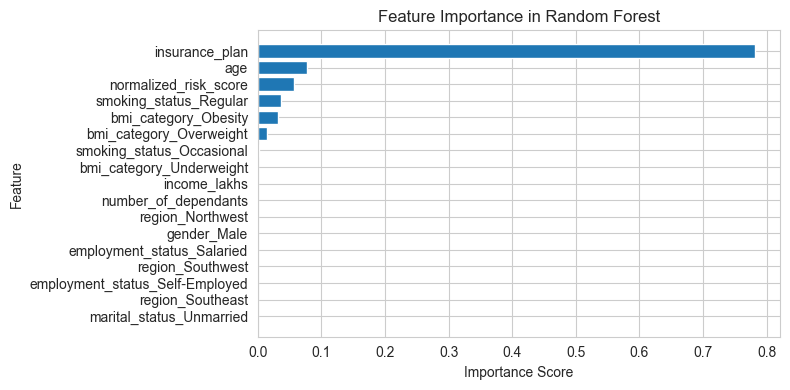

In [134]:
# Feature importance
feature_importance = best_model.feature_importances_

importance_df = pd.DataFrame({'Feature': X_train.columns,'Importance': feature_importance}).sort_values(by='Importance')

plt.figure(figsize=(8, 4))

plt.barh(importance_df['Feature'],importance_df['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest')

plt.tight_layout()
plt.show()

In [135]:
# Generate predictions using the best Random Forest model
y_pred = best_model.predict(X_test)

# Calculate prediction errors
residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

# Create a results DataFrame
results_df = pd.DataFrame({'actual': y_test,'predicted': y_pred,'diff': residuals,'diff_pct': residuals_pct})

results_df.head()

,actual,predicted,diff,diff_pct
19713,26895,26573.792706,-321.207294,-1.194301
14750,22734,22953.158330,219.158330,0.964011
19932,21198,21548.988764,350.988764,1.655764
29643,9100,9076.188974,-23.811026,-0.261660
17076,26434,26573.792706,139.792706,0.528837


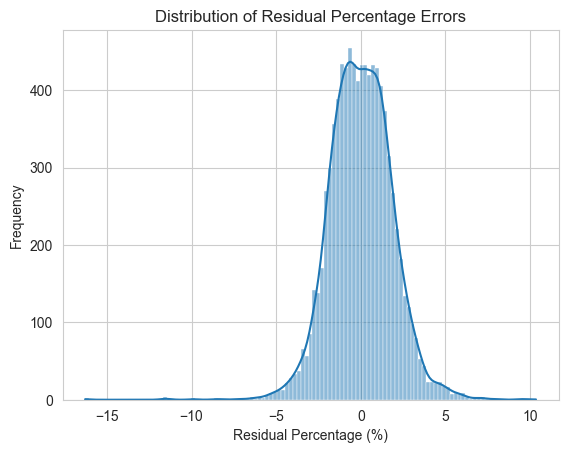

In [136]:
sns.histplot(results_df['diff_pct'], kde=True)

plt.title('Distribution of Residual Percentage Errors')
plt.xlabel('Residual Percentage (%)')
plt.ylabel('Frequency')

plt.savefig("../images/adult_model_residual_errors.png", dpi=300, bbox_inches="tight")
plt.show()

In [137]:
X_test.shape

(8947, 17)

In [138]:
results_df.shape

(8947, 4)

In [139]:
# Identify predictions with large percentage errors
error_threshold = 10

extreme_results_df = results_df[
    np.abs(results_df['diff_pct']) > error_threshold]

extreme_results_df.head()

,actual,predicted,diff,diff_pct
2964,12777,14099.376516,1322.376516,10.349664
26547,14885,12460.090662,-2424.909338,-16.290960
23887,23950,21182.504625,-2767.495375,-11.555304
9664,33494,29618.183374,-3875.816626,-11.571674
12617,12569,10527.334268,-2041.665732,-16.243661


In [140]:
extreme_results_df.shape

(7, 4)

In [141]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]

In [142]:
round(extreme_errors_pct, 4)

0.0782

We observe a very small proportion of extreme errors (**0.0782%**), indicating that the model performs well overall. Therefore, no further investigation into extreme prediction errors is required.